<a href="https://colab.research.google.com/github/Srikanth2001-tech/Predicting-Loan-Default-Risk-Using-ML/blob/main/predicting_loan_default_risk_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Loan Default Risk Using Machine Learning**

## **Introduction**
This notebook demonstrates how machine-learning models can be applied to predict whether a loan applicant will default.  
The dataset used is the **UCI Statlog German Credit Data**, compiled by Prof. Hans Hofmann (University of Hamburg).  
It contains socio-economic and financial information on 1 000 borrowers, labelled as **Good (1)** or **Bad (2)** credit risk.

### **Objectives**
1. Preprocess numerical and categorical features.  
2. Explore the dataset statistically and visually.  
3. Train traditional and ensemble models (Logistic Regression, Random Forest, XGBoost).  
4. Evaluate model performance using Accuracy, Precision, Recall, F1 Score, ROC–AUC.  
5. Identify key borrower attributes influencing default risk.


# **Import Libraries**

In [ ]:
# Import core data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine-learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# ===== Block 1a: Imports & setup =====
import time
from collections import defaultdict
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")


## **Load the German Credit Dataset**
We use the pre-processed numeric file `german.data-numeric`, which encodes categorical variables as numeric indicators.  
Each row corresponds to one applicant, and the last column (label) indicates creditworthiness:
* **1 = Good credit (no default)**
* **2 = Bad credit (default)**


In [ ]:
import pandas as pd

# Actual column names from the German Credit Data (numeric version)
columns = [
    "Status_of_existing_checking_account",
    "Duration_in_month",
    "Credit_history",
    "Purpose",
    "Credit_amount",
    "Savings_account_bonds",
    "Present_employment_since",
    "Installment_rate_in_percentage_of_disposable_income",
    "Personal_status_and_sex",
    "Other_debtors_guarantors",
    "Present_residence_since",
    "Property",
    "Age_in_years",
    "Other_installment_plans",
    "Housing",
    "Number_of_existing_credits_at_this_bank",
    "Job",
    "Number_of_people_being_liable_to_provide_maintenance_for",
    "Telephone",
    "Foreign_worker",
    "Target"  # 1 = Good, 2 = Bad credit risk
]

# Load dataset with actual column names
df = pd.read_csv(
    "/content/german.data-numeric",
    delim_whitespace=True,
    header=None,
    names=columns
)

# Display first few rows
df.head()


Status_of_existing_checking_account  Duration_in_month  \
1 6  4 12                                    5                  5   
2 48 2 60                                    1                  3   
4 12 4 21                                    1                  4   
1 42 2 79                                    1                  4   
  24 3 49                                    1                  3   

           Credit_history  Purpose  Credit_amount  Savings_account_bonds  \
1 6  4 12               3        4              1                     67   
2 48 2 60               2        2              1                     22   
4 12 4 21               3        3              1                     49   
1 42 2 79               3        4              2                     45   
  24 3 49               3        4              4                     53   

           Present_employment_since  \
1 6  4 12                         3   
2 48 2 60                         3   
4 12 4 21                         3   
1 42 2 79                         3   
  24 3 49                         3   

           Installment_rate_in_percentage_of_disposable_income  \
1 6  4 12                                                  2     
2 48 2 60                                                  1     
4 12 4 21                                                  1     
1 42 2 79                                                  1     
  24 3 49                                                  2     

           Personal_status_and_sex  Other_debtors_guarantors  ...  Property  \
1 6  4 12                        1                         2  ...         0   
2 48 2 60                        1                         1  ...         0   
4 12 4 21                        2                         1  ...         0   
1 42 2 79                        2                         1  ...         0   
  24 3 49                        2                         1  ...         1   

           Age_in_years  Other_installment_plans  Housing  \
1 6  4 12             0                        1        0   
2 48 2 60             0                        1        0   
4 12 4 21             0                        1        0   
1 42 2 79             0                        0        0   
  24 3 49             0                        1        0   

           Number_of_existing_credits_at_this_bank  Job  \
1 6  4 12                                        0    1   
2 48 2 60                                        0    1   
4 12 4 21                                        0    1   
1 42 2 79                                        0    0   
  24 3 49                                        0    0   

           Number_of_people_being_liable_to_provide_maintenance_for  \
1 6  4 12                                                  0          
2 48 2 60                                                  0          
4 12 4 21                                                  0          
1 42 2 79                                                  0          
  24 3 49                                                  0          

           Telephone  Foreign_worker  Target  
1 6  4 12          0               1       1  
2 48 2 60          0               1       2  
4 12 4 21          1               0       1  
1 42 2 79          0               1       1  
  24 3 49          0               1       2  

[5 rows x 21 columns]

## **Dataset Overview**
We inspect the dataset’s structure, data types, and check for any missing values.


In [ ]:
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
df.describe().T


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1000 entries, (np.int64(1), np.int64(6), np.int64(4), np.int64(12)) to (np.int64(2), np.int64(45), np.int64(4), np.int64(46))
Data columns (total 21 columns):
 #   Column                                                    Non-Null Count  Dtype
---  ------                                                    --------------  -----
 0   Status_of_existing_checking_account                       1000 non-null   int64
 1   Duration_in_month                                         1000 non-null   int64
 2   Credit_history                                            1000 non-null   int64
 3   Purpose                                                   1000 non-null   int64
 4   Credit_amount                                             1000 non-null   int64
 5   Savings_account_bonds                                     1000 non-null   int64
 6   Present_employment_since                                  1000 non-null   int64
 7   Installment_rate_in_p

,count,mean,std,min,25%,50%,75%,max
Status_of_existing_checking_account,1000.0,2.105,1.580023,1.0,1.0,1.0,3.0,5.0
Duration_in_month,1000.0,3.384,1.208306,1.0,3.0,3.0,5.0,5.0
Credit_history,1000.0,2.682,0.708080,1.0,2.0,3.0,3.0,4.0
Purpose,1000.0,2.845,1.103718,1.0,2.0,3.0,4.0,4.0
Credit_amount,1000.0,2.358,1.050209,1.0,1.0,2.0,3.0,4.0
Savings_account_bonds,1000.0,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Present_employment_since,1000.0,2.675,0.705601,1.0,3.0,3.0,3.0,3.0
Installment_rate_in_percentage_of_disposable_income,1000.0,1.407,0.577654,1.0,1.0,1.0,2.0,4.0
Personal_status_and_sex,1000.0,1.155,0.362086,1.0,1.0,1.0,1.0,2.0
Other_debtors_guarantors,1000.0,1.404,0.490943,1.0,1.0,1.0,2.0,2.0


## **Exploratory Data Analysis**
We visualise distributions of numerical features and the class balance of the target variable.


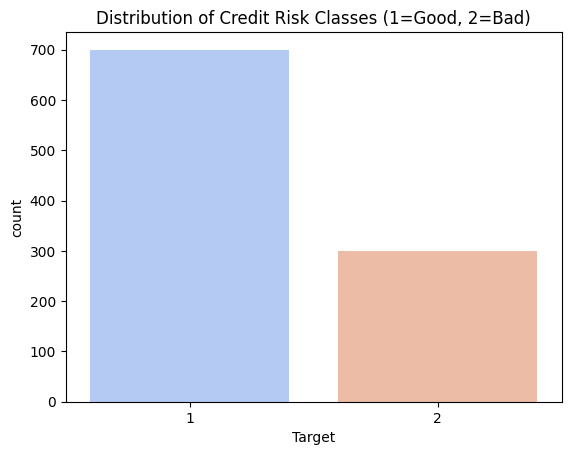

In [ ]:
# Target-class distribution
sns.countplot(x="Target", data=df, palette="coolwarm")
plt.title("Distribution of Credit Risk Classes (1=Good, 2=Bad)")
plt.show()


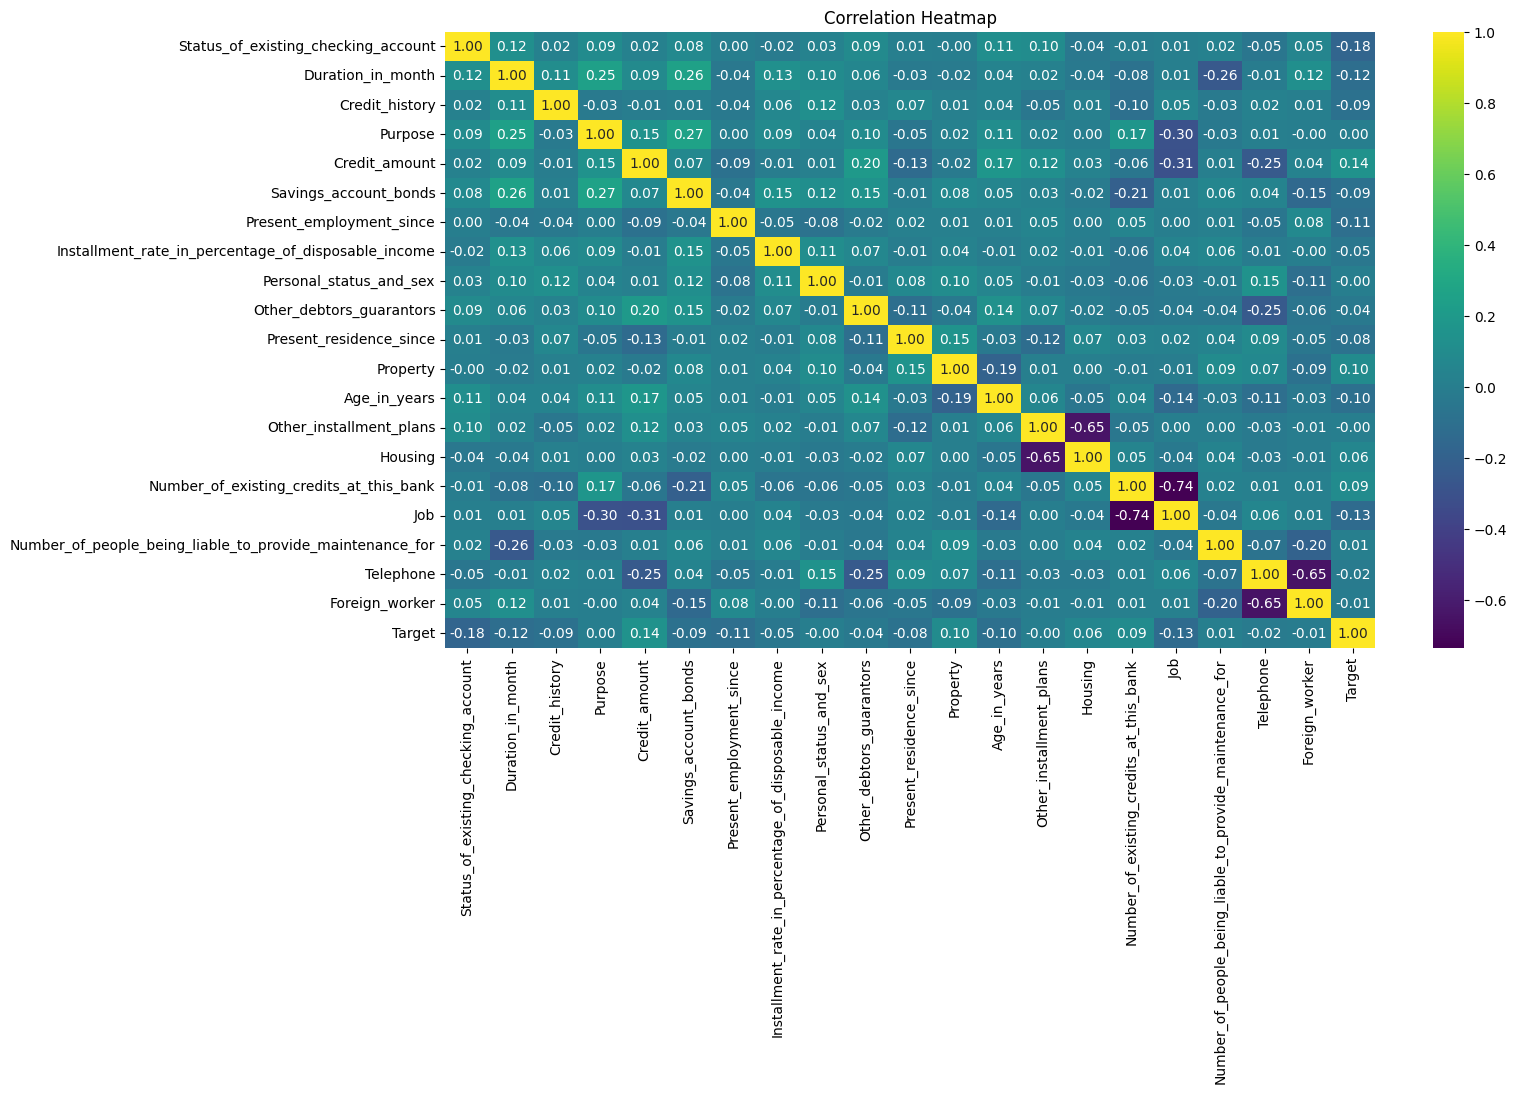

In [ ]:

# Correlation matrix
plt.figure(figsize=(15,8))
corr = df.corr()
sns.heatmap(corr, cmap="viridis", annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


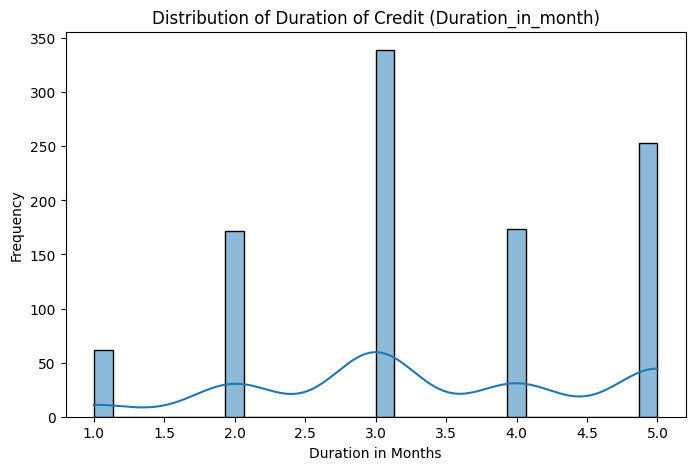

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Feature_1 (Duration of Credit in Months)
plt.figure(figsize=(8, 5))
sns.histplot(df['Duration_in_month'], kde=True, bins=30)
plt.title('Distribution of Duration of Credit (Duration_in_month)')
plt.xlabel('Duration in Months')
plt.ylabel('Frequency')
plt.show()


## **Data Preprocessing**
We split the data into training and test sets (80/20) and apply standardisation to numerical features.


In [ ]:
X = df.drop("Target", axis=1)
y = df["Target"].apply(lambda x: 0 if x==1 else 1)  # 0=Good, 1=Bad

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Container to collect the results of the models

In [ ]:

# Collect per-model metrics and timings
METRICS_SUMMARY = []   # list of dicts, one per model
TIME_SUMMARY    = []   # list of dicts, one per model

# Store ROC data for the combined ROC plot later
# Mapping: model_name -> (fpr, tpr, auc)
ROC_CURVES      = {}


Functions for evaluations, ROC curve, Confusion Matrix

In [ ]:
# ===== Block 1c: Evaluation utility =====
from sklearn.metrics import roc_curve

def evaluate_model(model, model_name,
                   X_train, y_train,
                   X_test, y_test,
                   plot_cm=True, plot_roc=True):
    """
    Fits `model`, measures train & test time, computes train/test metrics,
    plots Confusion Matrix and ROC curve (test), and stores summaries.
    """

    # -------- Train (fit) time --------
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    # -------- Predictions & test time --------
    # We measure inference as probability/scores + hard predict.
    t1 = time.perf_counter()
    if hasattr(model, "predict_proba"):
        y_proba_test = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        # Scale decision_function outputs to [0,1] for ROC if needed
        from sklearn.preprocessing import MinMaxScaler
        scores = model.decision_function(X_test).reshape(-1, 1)
        y_proba_test = MinMaxScaler().fit_transform(scores).ravel()
    else:
        # Fallback to hard labels (not ideal for ROC)
        y_proba_test = model.predict(X_test)
    y_pred_test = model.predict(X_test)
    test_time = time.perf_counter() - t1

    # -------- Train-set predictions --------
    if hasattr(model, "predict_proba"):
        y_proba_train = model.predict_proba(X_train)[:, 1]
    elif hasattr(model, "decision_function"):
        from sklearn.preprocessing import MinMaxScaler
        scores_tr = model.decision_function(X_train).reshape(-1, 1)
        y_proba_train = MinMaxScaler().fit_transform(scores_tr).ravel()
    else:
        y_proba_train = model.predict(X_train)

    y_pred_train = model.predict(X_train)

    # -------- Metrics (Train) --------
    acc_tr  = accuracy_score(y_train, y_pred_train)
    prec_tr, rec_tr, f1_tr, _ = precision_recall_fscore_support(
        y_train, y_pred_train, average="binary", zero_division=0
    )
    auc_tr  = roc_auc_score(y_train, y_proba_train)

    # -------- Metrics (Test) --------
    acc_te  = accuracy_score(y_test, y_pred_test)
    prec_te, rec_te, f1_te, _ = precision_recall_fscore_support(
        y_test, y_pred_test, average="binary", zero_division=0
    )
    auc_te  = roc_auc_score(y_test, y_proba_test)

    # -------- Store summaries --------
    METRICS_SUMMARY.append({
        "Model": model_name,
        "Train_Accuracy": acc_tr,
        "Train_Precision": prec_tr,
        "Train_Recall": rec_tr,
        "Train_F1": f1_tr,
        "Train_ROC_AUC": auc_tr,
        "Test_Accuracy": acc_te,
        "Test_Precision": prec_te,
        "Test_Recall": rec_te,
        "Test_F1": f1_te,
        "Test_ROC_AUC": auc_te,
    })

    TIME_SUMMARY.append({
        "Model": model_name,
        "Train_Time_s": train_time,
        "Test_Time_s": test_time
    })

    # -------- Save ROC data for combined plot --------
    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    ROC_CURVES[model_name] = (fpr, tpr, auc_te)

    # -------- Plots --------
    if plot_cm:
        cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
        plt.figure(figsize=(4.5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cbar=False,
                    xticklabels=["Good (0)", "Bad (1)"],
                    yticklabels=["Good (0)", "Bad (1)"])
        plt.title(f"{model_name} — Confusion Matrix (Test)")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

    if plot_roc:
        RocCurveDisplay.from_predictions(y_test, y_proba_test, name=model_name)
        plt.title(f"{model_name} — ROC Curve (Test)")
        plt.tight_layout()
        plt.show()

    return model


# **Model Training**

**Logistic Regression**

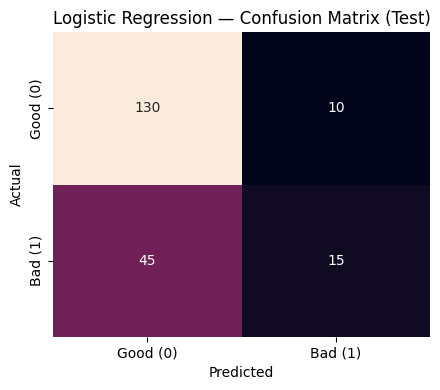

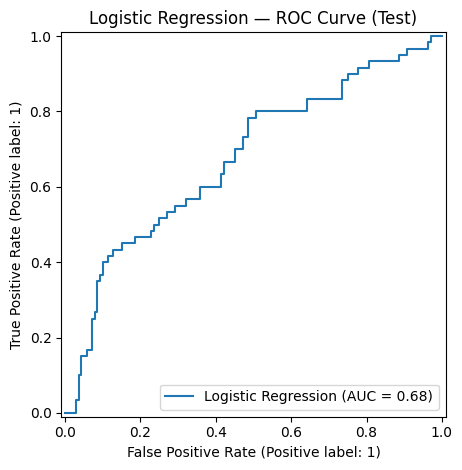

=== Logistic Regression — Classification Report (Test) ===
              precision    recall  f1-score   support

    Good (0)       0.74      0.93      0.83       140
     Bad (1)       0.60      0.25      0.35        60

    accuracy                           0.72       200
   macro avg       0.67      0.59      0.59       200
weighted avg       0.70      0.72      0.68       200

Summary (Train/Test): Acc 0.7312/0.7250, Precision 0.6050/0.6000, Recall 0.3000/0.2500, F1 0.4011/0.3529, AUC 0.7337/0.6755


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

logreg = LogisticRegression(max_iter=1000, n_jobs=None, random_state=42)

# Fit, time, metrics, CM & ROC (plots)
logreg = evaluate_model(
    logreg, "Logistic Regression",
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

# Printed evaluation (Test)
y_pred_lr = logreg.predict(X_test_scaled)
print("=== Logistic Regression — Classification Report (Test) ===")
print(classification_report(y_test, y_pred_lr, target_names=["Good (0)", "Bad (1)"]))

m = METRICS_SUMMARY[-1]
print("Summary (Train/Test): "
      f"Acc {m['Train_Accuracy']:.4f}/{m['Test_Accuracy']:.4f}, "
      f"Precision {m['Train_Precision']:.4f}/{m['Test_Precision']:.4f}, "
      f"Recall {m['Train_Recall']:.4f}/{m['Test_Recall']:.4f}, "
      f"F1 {m['Train_F1']:.4f}/{m['Test_F1']:.4f}, "
      f"AUC {m['Train_ROC_AUC']:.4f}/{m['Test_ROC_AUC']:.4f}")


**Random Forest**

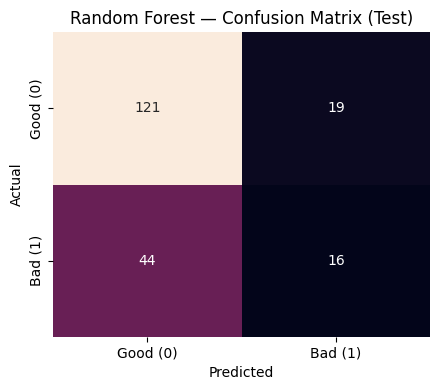

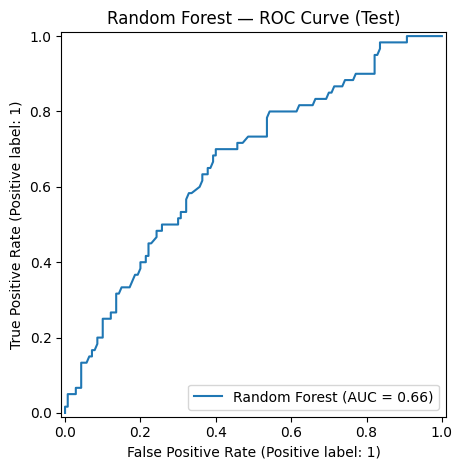

=== Random Forest — Classification Report (Test) ===
              precision    recall  f1-score   support

    Good (0)       0.73      0.86      0.79       140
     Bad (1)       0.46      0.27      0.34        60

    accuracy                           0.69       200
   macro avg       0.60      0.57      0.57       200
weighted avg       0.65      0.69      0.66       200

Summary (Train/Test): Acc 0.9988/0.6850, Precision 1.0000/0.4571, Recall 0.9958/0.2667, F1 0.9979/0.3368, AUC 1.0000/0.6640


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

rf = evaluate_model(
    rf, "Random Forest",
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

y_pred_rf = rf.predict(X_test_scaled)
print("=== Random Forest — Classification Report (Test) ===")
print(classification_report(y_test, y_pred_rf, target_names=["Good (0)", "Bad (1)"]))

m = METRICS_SUMMARY[-1]
print("Summary (Train/Test): "
      f"Acc {m['Train_Accuracy']:.4f}/{m['Test_Accuracy']:.4f}, "
      f"Precision {m['Train_Precision']:.4f}/{m['Test_Precision']:.4f}, "
      f"Recall {m['Train_Recall']:.4f}/{m['Test_Recall']:.4f}, "
      f"F1 {m['Train_F1']:.4f}/{m['Test_F1']:.4f}, "
      f"AUC {m['Train_ROC_AUC']:.4f}/{m['Test_ROC_AUC']:.4f}")


**XGBoost**

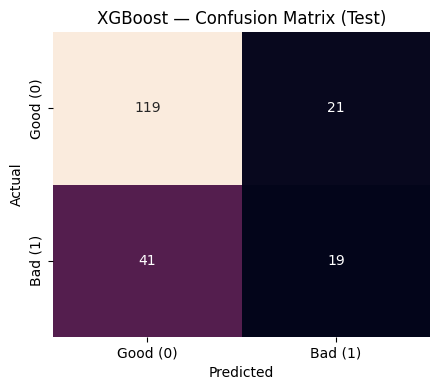

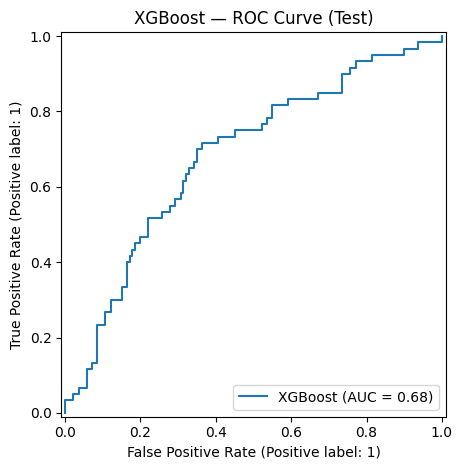

=== XGBoost — Classification Report (Test) ===
              precision    recall  f1-score   support

    Good (0)       0.74      0.85      0.79       140
     Bad (1)       0.47      0.32      0.38        60

    accuracy                           0.69       200
   macro avg       0.61      0.58      0.59       200
weighted avg       0.66      0.69      0.67       200

Summary (Train/Test): Acc 0.9038/0.6900, Precision 0.9405/0.4750, Recall 0.7250/0.3167, F1 0.8188/0.3800, AUC 0.9600/0.6814


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

xgb = evaluate_model(
    xgb, "XGBoost",
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

y_pred_xgb = xgb.predict(X_test_scaled)
print("=== XGBoost — Classification Report (Test) ===")
print(classification_report(y_test, y_pred_xgb, target_names=["Good (0)", "Bad (1)"]))

m = METRICS_SUMMARY[-1]
print("Summary (Train/Test): "
      f"Acc {m['Train_Accuracy']:.4f}/{m['Test_Accuracy']:.4f}, "
      f"Precision {m['Train_Precision']:.4f}/{m['Test_Precision']:.4f}, "
      f"Recall {m['Train_Recall']:.4f}/{m['Test_Recall']:.4f}, "
      f"F1 {m['Train_F1']:.4f}/{m['Test_F1']:.4f}, "
      f"AUC {m['Train_ROC_AUC']:.4f}/{m['Test_ROC_AUC']:.4f}")


**Support Vector Machine**

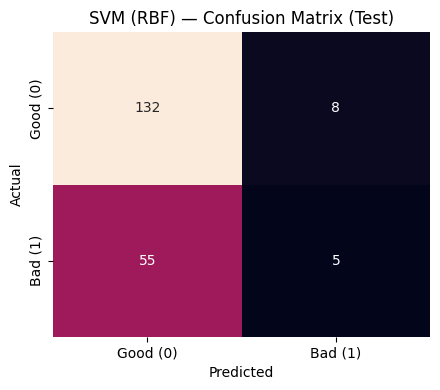

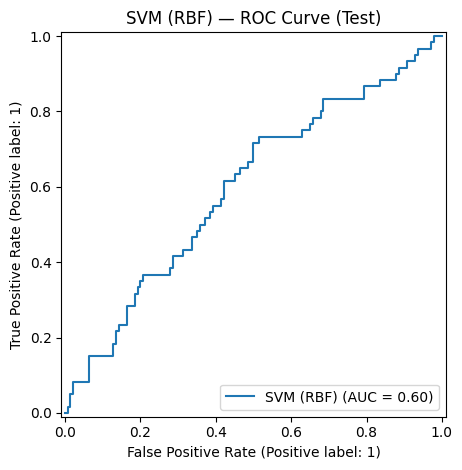

=== SVM (RBF) — Classification Report (Test) ===
              precision    recall  f1-score   support

    Good (0)       0.71      0.94      0.81       140
     Bad (1)       0.38      0.08      0.14        60

    accuracy                           0.69       200
   macro avg       0.55      0.51      0.47       200
weighted avg       0.61      0.69      0.61       200

Summary (Train/Test): Acc 0.7688/0.6850, Precision 0.9365/0.3846, Recall 0.2458/0.0833, F1 0.3894/0.1370, AUC 0.8920/0.5975


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm = evaluate_model(
    svm, "SVM (RBF)",
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

y_pred_svm = svm.predict(X_test_scaled)
print("=== SVM (RBF) — Classification Report (Test) ===")
print(classification_report(y_test, y_pred_svm, target_names=["Good (0)", "Bad (1)"]))

m = METRICS_SUMMARY[-1]
print("Summary (Train/Test): "
      f"Acc {m['Train_Accuracy']:.4f}/{m['Test_Accuracy']:.4f}, "
      f"Precision {m['Train_Precision']:.4f}/{m['Test_Precision']:.4f}, "
      f"Recall {m['Train_Recall']:.4f}/{m['Test_Recall']:.4f}, "
      f"F1 {m['Train_F1']:.4f}/{m['Test_F1']:.4f}, "
      f"AUC {m['Train_ROC_AUC']:.4f}/{m['Test_ROC_AUC']:.4f}")


**KNN**

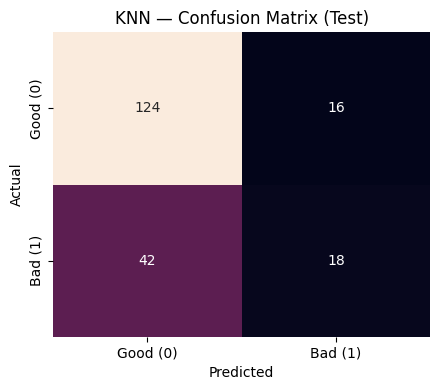

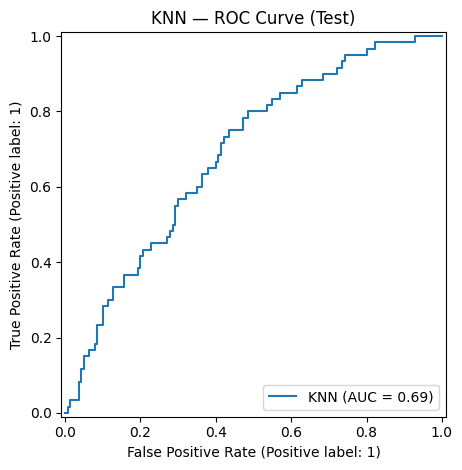

=== KNN — Classification Report (Test) ===
              precision    recall  f1-score   support

    Good (0)       0.75      0.89      0.81       140
     Bad (1)       0.53      0.30      0.38        60

    accuracy                           0.71       200
   macro avg       0.64      0.59      0.60       200
weighted avg       0.68      0.71      0.68       200

Summary (Train/Test): Acc 0.9988/0.7100, Precision 1.0000/0.5294, Recall 0.9958/0.3000, F1 0.9979/0.3830, AUC 1.0000/0.6870


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="minkowski",
    p=2,
    n_jobs=-1
)

knn = evaluate_model(
    knn, "KNN",
    X_train_scaled, y_train,
    X_test_scaled, y_test
)

y_pred_knn = knn.predict(X_test_scaled)
print("=== KNN — Classification Report (Test) ===")
print(classification_report(y_test, y_pred_knn, target_names=["Good (0)", "Bad (1)"]))

m = METRICS_SUMMARY[-1]
print("Summary (Train/Test): "
      f"Acc {m['Train_Accuracy']:.4f}/{m['Test_Accuracy']:.4f}, "
      f"Precision {m['Train_Precision']:.4f}/{m['Test_Precision']:.4f}, "
      f"Recall {m['Train_Recall']:.4f}/{m['Test_Recall']:.4f}, "
      f"F1 {m['Train_F1']:.4f}/{m['Test_F1']:.4f}, "
      f"AUC {m['Train_ROC_AUC']:.4f}/{m['Test_ROC_AUC']:.4f}")


**Summarized Evaluation Metrics and Train-Test Time**

In [ ]:
# Create summary DataFrames
metrics_df = pd.DataFrame(METRICS_SUMMARY)
time_df    = pd.DataFrame(TIME_SUMMARY)

# Sort by best Test ROC_AUC (descending)
metrics_df = metrics_df.sort_values(by="Test_ROC_AUC", ascending=False).reset_index(drop=True)
time_df    = time_df.merge(metrics_df[["Model"]], on="Model", how="right")  # align order with metrics table

# Display with reasonable formatting
def style_pct(df, cols):
    return df.style.format({c: "{:.4f}" for c in cols})

display_cols_metrics = [
    "Model",
    "Train_Accuracy","Train_Precision","Train_Recall","Train_F1","Train_ROC_AUC",
    "Test_Accuracy","Test_Precision","Test_Recall","Test_F1","Test_ROC_AUC",
]
display_cols_time = ["Model","Train_Time_s","Test_Time_s"]

print("=== Summarized Evaluation Metrics ===")
display(style_pct(metrics_df[display_cols_metrics],
                  [c for c in display_cols_metrics if c != "Model"]))

print("\n=== Summarized Train/Test Time (seconds) ===")
display(time_df[display_cols_time].style.format({"Train_Time_s":"{:.4f}","Test_Time_s":"{:.4f}"}))


=== Summarized Evaluation Metrics ===


,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Train_ROC_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,KNN,0.9988,1.0000,0.9958,0.9979,1.0000,0.7100,0.5294,0.3000,0.3830,0.6870
1,XGBoost,0.9038,0.9405,0.7250,0.8188,0.9600,0.6900,0.4750,0.3167,0.3800,0.6814
2,Logistic Regression,0.7312,0.6050,0.3000,0.4011,0.7337,0.7250,0.6000,0.2500,0.3529,0.6755
3,Random Forest,0.9988,1.0000,0.9958,0.9979,1.0000,0.6850,0.4571,0.2667,0.3368,0.6640
4,SVM (RBF),0.7688,0.9365,0.2458,0.3894,0.8920,0.6850,0.3846,0.0833,0.1370,0.5975



=== Summarized Train/Test Time (seconds) ===


,Model,Train_Time_s,Test_Time_s
0,KNN,0.0025,0.0081
1,XGBoost,0.0865,0.0046
2,Logistic Regression,0.0076,0.0012
3,Random Forest,1.8457,0.2800
4,SVM (RBF),0.1686,0.0144


**Combined ROC Curve for Trained Models**

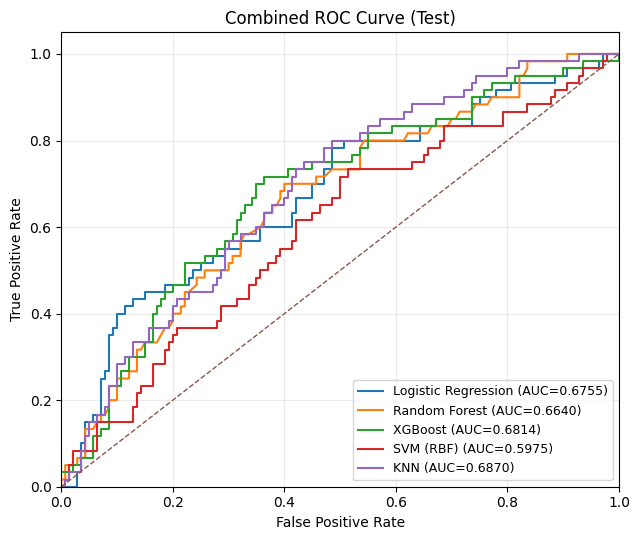

In [ ]:
from sklearn.metrics import auc

plt.figure(figsize=(6.5, 5.5))

for name, (fpr, tpr, auc_val) in ROC_CURVES.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")

# Chance line
plt.plot([0,1], [0,1], linestyle="--", linewidth=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curve (Test)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**K-Fold Cross Validation**

In [ ]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "auc": "roc_auc",
    "acc": "accuracy",
    "f1":  "f1"
}

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, n_jobs=-1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        objective="binary:logistic", eval_metric="logloss",
        n_jobs=-1, random_state=42
    ),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=15, weights="distance", p=2))
    ]),
}

rows = []
for name, est in models.items():
    cvres = cross_validate(
        est, X, y,
        cv=kf, scoring=scoring,
        n_jobs=-1, return_train_score=False
    )
    rows.append({
        "Model": name,
        "AUC_mean": np.mean(cvres["test_auc"]),
        "AUC_std":  np.std(cvres["test_auc"]),
        "ACC_mean": np.mean(cvres["test_acc"]),
        "ACC_std":  np.std(cvres["test_acc"]),
        "F1_mean":  np.mean(cvres["test_f1"]),
        "F1_std":   np.std(cvres["test_f1"]),
        "FitTime_mean_s":   np.mean(cvres["fit_time"]),
        "ScoreTime_mean_s": np.mean(cvres["score_time"]),
    })

kfold_table = pd.DataFrame(rows).sort_values("AUC_mean", ascending=False).reset_index(drop=True)
print("=== 5-Fold KFold Results (non-stratified) ===")
display(kfold_table.style.format({
    "AUC_mean": "{:.4f}", "AUC_std": "{:.4f}",
    "ACC_mean": "{:.4f}", "ACC_std": "{:.4f}",
    "F1_mean":  "{:.4f}", "F1_std":  "{:.4f}",
    "FitTime_mean_s": "{:.4f}", "ScoreTime_mean_s": "{:.4f}",
}))

=== 5-Fold KFold Results (non-stratified) ===


,Model,AUC_mean,AUC_std,ACC_mean,ACC_std,F1_mean,F1_std,FitTime_mean_s,ScoreTime_mean_s
0,Random Forest,0.6830,0.0254,0.7010,0.0322,0.3425,0.0257,1.9012,0.3085
1,Logistic Regression,0.6802,0.0227,0.7110,0.0198,0.3262,0.0414,0.0145,0.0158
2,KNN,0.6690,0.0444,0.6780,0.0277,0.2785,0.0399,0.0140,0.0433
3,XGBoost,0.6682,0.0215,0.7080,0.0234,0.3899,0.0542,0.1351,0.0293
4,SVM (RBF),0.6503,0.0199,0.6990,0.0250,0.1839,0.0423,0.2554,0.0456
